In [1]:
#Import required libraries for data handling, numerical analysis, and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Load the three cleaned datasets from Milestone 1 preprocessing
demographics = pd.read_csv("demographics_clean.csv")
social = pd.read_csv("social_clean.csv")
transactions = pd.read_csv("transactions_clean.csv")
# Preview the Demographics dataset to confirm it loaded correctly
demographics.head()

,CustomerID,Age,Gender,Location,IncomeLevel,SignupDate
0,9207fa75-5758-48d1-94ad-19c041e0520f,51.0,Female,Jensenberg,Low,2022-11-17
1,5fb09cd8-a473-46f7-80bd-6e49cf509078,NaN,Female,Castilloport,High,2020-07-21
2,c139496e-cc89-498a-bd90-1fb4627b6cff,37.0,Male,Lake Jennifertown,NaN,2021-01-01
3,50118139-7264-428f-81cc-a25fddc5d6dd,44.0,Male,Port Carl,Medium,2024-10-06
4,7d1f2bbc-8d16-4fbc-9b37-ece3324e8ed4,50.0,Female,Jessebury,High,2023-08-24


In [2]:
# Additional NumPy statistical computations for Age
print("Age - Mean:", np.mean(demographics["Age"].dropna()))
print("Age - Median:", np.median(demographics["Age"].dropna()))
print("Age - Standard Deviation:", np.std(demographics["Age"].dropna(), ddof=1))
print("Age - Variance:", np.var(demographics["Age"].dropna(), ddof=1))
print("Age - Minimum:", np.min(demographics["Age"].dropna()))
print("Age - Maximum:", np.max(demographics["Age"].dropna()))

Age - Mean: 45.42167342425359
Age - Median: 45.0
Age - Standard Deviation: 19.731359576533006
Age - Variance: 389.326550738440
Age - Minimum: -1.0
Age - Maximum: 150.0


In [3]:
# Additional NumPy statistical computations for Transaction Amount
print("Amount_Clean - Mean:", np.mean(transactions["Amount_Clean"].dropna()))
print("Amount_Clean - Median:", np.median(transactions["Amount_Clean"].dropna()))
print("Amount_Clean - Standard Deviation:", np.std(transactions["Amount_Clean"].dropna(), ddof=1))
print("Amount_Clean - Variance:", np.var(transactions["Amount_Clean"].dropna(), ddof=1))
print("Amount_Clean - Minimum:", np.min(transactions["Amount_Clean"].dropna()))
print("Amount_Clean - Maximum:", np.max(transactions["Amount_Clean"].dropna()))

Amount_Clean - Mean: 489.78891931902285
Amount_Clean - Median: 496.625
Amount_Clean - Standard Deviation: 299.2394527529937
Amount_Clean - Variance: 89544.25008391115
Amount_Clean - Minimum: -100.0
Amount_Clean - Maximum: 999.86


In [4]:
#  Calculate the 25th, 50th (median), and 75th percentiles of Age
#  This shows how customer ages are spread out, separate from the extreme Age anomalies (-1, 150)

age_percentiles = np.percentile(demographics["Age"].dropna(), [25, 50, 75])
print("25th, 50th, 75th percentiles of Age:", age_percentiles)

25th, 50th, 75th percentiles of Age: [31. 45. 58.]


In [5]:
#  Calculate the 25th, 50th (median), and 75th percentiles of Transaction Amount
#  This shows how transaction values are spread out, separate from the extreme anomalies (<= 0)

amount_percentiles = np.percentile(transactions["Amount_Clean"].dropna(), [25, 50, 75])
print("25th, 50th, 75th percentiles of Transaction Amount:", amount_percentiles)

25th, 50th, 75th percentiles of Transaction Amount: [228.24   496.625  746.6975]


In [6]:
sentiment_counts = social["Sentiment"].value_counts()
print(sentiment_counts)

Sentiment
Positive         905
Neutral          874
Negative         866
Unknown          309
Very Negative     34
Very Positive     32
Name: count, dtype: int64


### Identifying Variables for Visualization

Based on the Milestone 1 EDA findings, the following variables and observations were identified as important for visualization:

 **Age (Demographics):** Contains 63 anomalous values (below 0 or above 100, including -1 and 150) that could not be clearly seen in raw statistics alone a histogram would visually reveal where these anomalies cluster.

 **Transaction Amount (Transactions):** Contains anomalous negative values, including a recurring 100, which represent a significant portion of the data  a histogram and box plot would show how these compare to the overall spread.

 **Sentiment (Social Media):** Shows a clear class imbalance (Very Negative: 34, Very Positive: 32 vs. 800-900 for other categories) that is easier to communicate visually through a bar/count plot than through raw numbers.
 
 **Age vs. Transaction Amount relationship:** The calculated correlation (0.021) suggested little to no relationship, which is best confirmed visually through a scatter plot and correlation heatmap.

We prioritized these variables because they are directly tied to the anomalies, imbalances, and relationships identified during Milestone 1 (EDA), and visualizing them makes these findings clearer and easier to explain to FinMark Corporation's broader team.

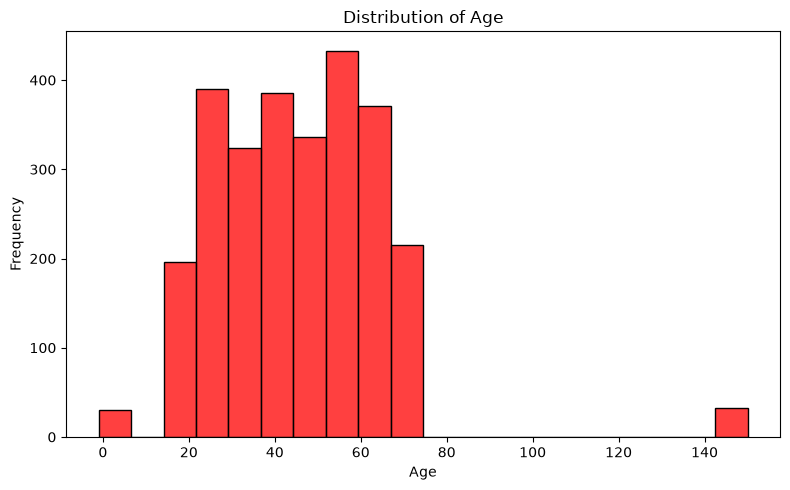

In [7]:
# Visualize the distribution of Age, including the anomalous values (-1 and 150)
plt.figure(figsize=(8,5))
sns.histplot(demographics["Age"].dropna(), bins=20, color="red")
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Interpretation:** Most of FinMark's customers fall between roughly 15 and 75 years old, representing the realistic range of their customer base. However, two small clusters sit well outside this range near 0 (the -1 anomaly) and near 150  confirming that the 63 previously identified Age anomalies are concentrated at the extreme edges rather than scattered throughout. For FinMark's future machine learning activities, such as customer segmentation by age group, these invalid values would need to be corrected or removed first, since they could distort age-based groupings and lead to inaccurate customer profiles.

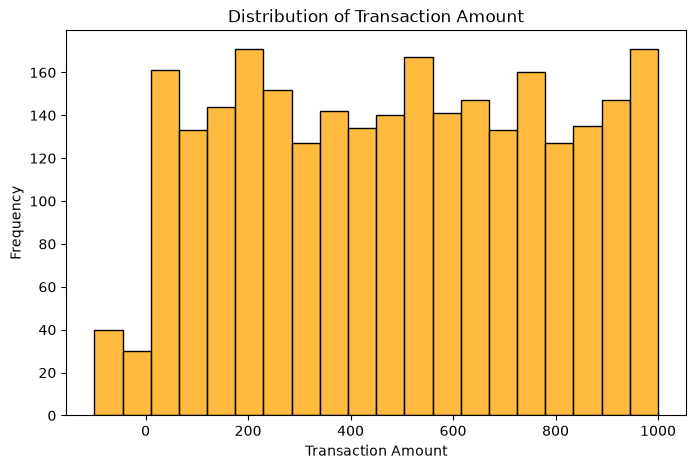

In [8]:
# Visualize the distribution of Transaction Amount, including anomalies (negative/zero values)
plt.figure(figsize=(8,5))
sns.histplot(transactions["Amount_Clean"].dropna(), bins=20, color="orange")
plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Interpretation:** Transaction amounts are spread fairly evenly between 0 and 1000, with a smaller but distinct cluster of negative values (including the repeating -100). This confirms that negative/invalid transactions are a consistent, not random, data issue  potentially linked to refunds or a system default value  and should be investigated before being used in financial modeling.

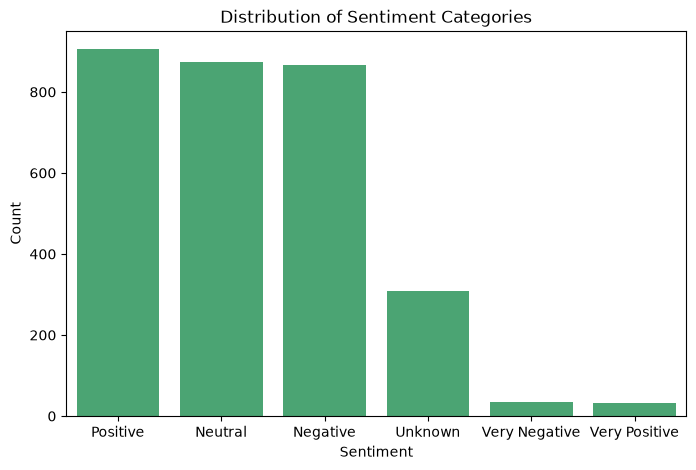

In [9]:
# Visualize the distribution of Sentiment categories, showing the class imbalance
plt.figure(figsize=(8,5))
sns.countplot(data=social, x="Sentiment", order=social["Sentiment"].value_counts().index, color="mediumseagreen")
plt.title("Distribution of Sentiment Categories")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**Interpretation:** Positive, Neutral, and Negative sentiments are fairly balanced (approximately 866–905 each). The "Unknown" category (309 records, ~10% of the dataset) is the fourth-largest bar in the chart, but it does not represent a real sentiment — it reflects interactions where Sentiment was missing in the original data and was imputed as "Unknown" during Week 3 preprocessing, so it should be read separately from the five genuine sentiment classes. Among the real sentiment classes, Very Negative and Very Positive are dramatically smaller (32–34 each) than Positive, Neutral, and Negative, confirming a significant class imbalance. This is directly relevant to FinMark Corporation — a sentiment classification model trained on this data would likely struggle to correctly predict the extreme classes without techniques like class weighting or resampling, and the "Unknown" records should likely be excluded from training a sentiment classifier altogether, since they do not reflect an actual customer sentiment.

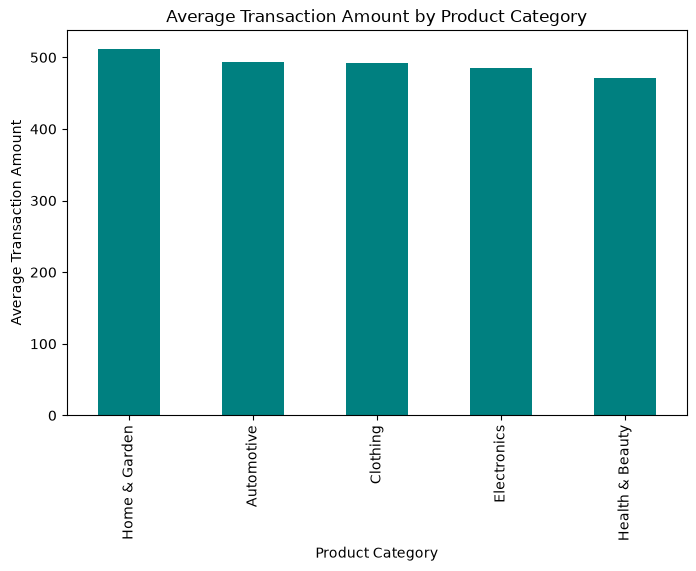

In [10]:
# Compare average Transaction Amount across different Product Categories
avg_amount_by_category = transactions.groupby("ProductCategory")["Amount_Clean"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
avg_amount_by_category.plot(kind="bar", color="teal")
plt.title("Average Transaction Amount by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Transaction Amount")
plt.tight_layout()
plt.show()

**Interpretation:** Average transaction amounts across the five product categories are fairly close to each other, ranging from about 470 (Health & Beauty) to about 510 (Home & Garden)  a difference of only about 40 units. Unlike the Sentiment categories, which showed a clear imbalance, no single product category stands out as dominating customer spending; the categories are relatively balanced in terms of average transaction value. For FinMark Corporation, this suggests that ProductCategory alone may not be a strong differentiator for predicting transaction amount, and future modeling efforts may need to combine it with other variables (such as PaymentMethod or customer demographics) to better explain spending behavior.

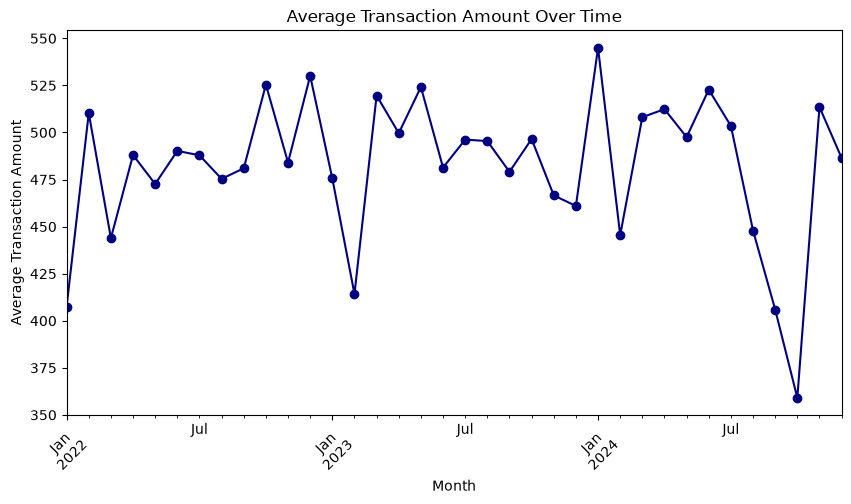

In [11]:
# Convert TransactionDate to a proper date type
transactions["TransactionDate"] = pd.to_datetime(transactions["TransactionDate"], errors="coerce")

# Group by month and calculate the average Transaction Amount
monthly_avg_amount = transactions.groupby(transactions["TransactionDate"].dt.to_period("M"))["Amount_Clean"].mean()

# Line chart showing average Transaction Amount trend over time
plt.figure(figsize=(10,5))
monthly_avg_amount.plot(kind="line", marker="o", color="navy")
plt.title("Average Transaction Amount Over Time")
plt.xlabel("Month")
plt.ylabel("Average Transaction Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation:** The average transaction amount fluctuates month to month between roughly 360 and 550, without showing a clear long-term upward or downward trend  spending levels appear relatively stable overall, just with normal variation. A few points stand out, however: there's a noticeable dip around mid-2023 (down to about 414) and another sharper dip in mid-2024 (down to about 360, the lowest point in the dataset), as well as a sharp spike around January 2024 (up to about 545).FinMark Corporation, these fluctuations especially the unusually low months  could be worth investigating further to understand whether they're tied to seasonal customer behavior, data quality issues, or specific business events, since they represent meaningful deviations from the otherwise steady pattern.

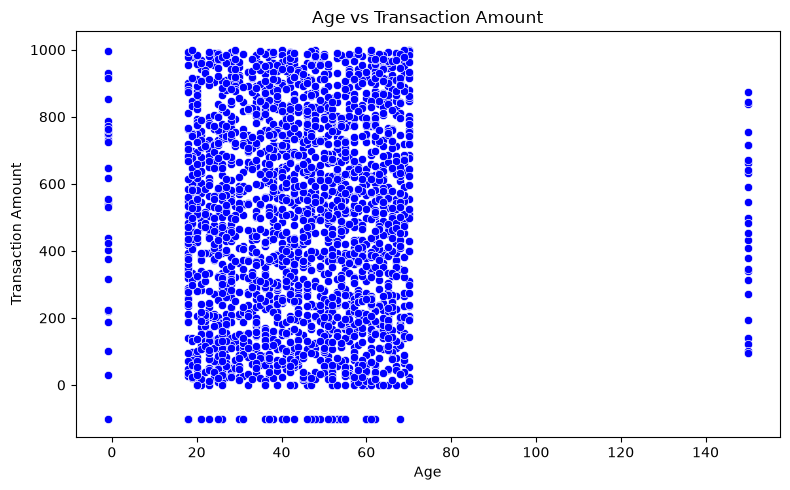

In [12]:
# Merge Demographics and Transactions on CustomerID to compare Age and Transaction Amount
age_amount = pd.merge(demographics[["CustomerID", "Age"]], transactions[["CustomerID", "Amount_Clean"]], on="CustomerID", how="inner")
age_amount = age_amount.dropna(subset=["Age", "Amount_Clean"])

# Visualize the relationship between Age and Transaction Amount
plt.figure(figsize=(8,5))
sns.scatterplot(data=age_amount, x="Age", y="Amount_Clean", color="blue")
plt.title("Age vs Transaction Amount")
plt.xlabel("Age")
plt.ylabel("Transaction Amount")
plt.tight_layout()
plt.show()

**Interpretation:**  The data points form a wide, scattered cloud with no visible upward or downward trend, visually confirming the near-zero correlation (0.021) calculated earlier. This suggests Age alone is not a useful predictor of spending amount, and future modeling efforts may need to consider other variables instead.

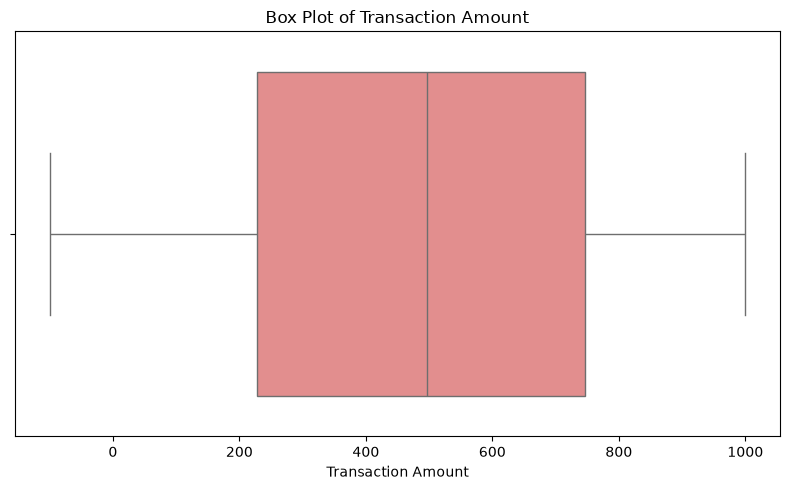

In [13]:
# Box plot of Transaction Amount to visually highlight outliers/anomalies
plt.figure(figsize=(8,5))

sns.boxplot(x=transactions["Amount_Clean"], color="lightcoral")
plt.title("Box Plot of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.tight_layout()
plt.show()

**Interpretation:**  Interestingly, the box plot's standard outlier detection did not flag the negative transaction values as statistical outliers, since the overall data spread is wide enough to include them within the whisker range. This highlights an important consideration for future preprocessing: statistical outlier methods alone aren't sufficient here  domain knowledge (knowing that negative transaction amounts are impossible) is necessary to catch data-quality issues that purely statistical methods might miss.

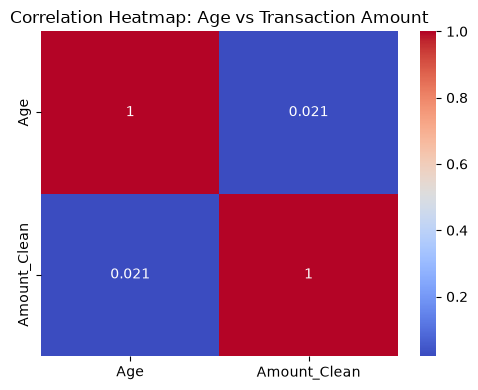

In [14]:
# Correlation heatmap between Age and Transaction Amount
plt.figure(figsize=(5,4))
correlation_matrix = age_amount[["Age", "Amount_Clean"]].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap: Age vs Transaction Amount")
plt.tight_layout()
plt.show()

**Interpretation:** The heatmap visually reinforces the scatter plot's finding  Age and Transaction Amount share a correlation of just 0.021, indicating essentially no linear relationship between a customer's age and how much they spend. For FinMark Corporation, this means Age alone would not be a reliable predictor for future machine learning models focused on tasks like purchase behavior prediction or customer segmentation. This supports the earlier conclusion that additional variables beyond Age such as Platform usage, Sentiment, or ProductCategory would likely be needed to meaningfully predict or explain transaction behavior.

## Summary of Visualization Findings

The visualizations in this notebook extend the Milestone 1 EDA by confirming, and in some cases sharpening, the data-quality and relationship findings identified earlier: the Age and Transaction Amount anomalies are concentrated at the extreme edges of their distributions rather than scattered randomly; the Sentiment class imbalance is severe once the "Unknown" records are set aside; average spending is relatively stable across product categories and over time, aside from a few months worth investigating further; and the near-zero Age–Amount correlation is visually confirmed by both the scatter plot and the correlation heatmap. Together with the box plot showing that standard IQR-based outlier detection misses the negative transaction values entirely, these findings reinforce that domain knowledge not just statistical thresholds is needed to fully resolve FinMark's data-quality issues before this data is used in future machine learning models.